In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

BASE = Path('/content/drive/MyDrive/Diplom2')
META = BASE / 'data' / 'meta'
PRE_DIR = BASE / 'data' / 'preprocessed'
sys.path.insert(0, str(BASE / 'code'))

Mounted at /content/drive


In [ ]:
meta = pd.read_csv(META / 'meta_raw.csv')
signals = np.load(PRE_DIR / 'signals_raw.npy', mmap_mode='r')
print('meta:', meta.shape, '| signals:', signals.shape)
meta.head()

/tmp/ipykernel_14724/875043772.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  meta = pd.read_csv(META / 'meta_raw.csv')


meta: (92469, 9) | signals: (92469, 2800, 12)


,record_name,record_path,dataset_group,age,sex_code,chagas_label,fs_hz,duration_sec,signal_idx
0,1000010,/content/work/prepared/code15_base/1000010,code15,40.0,0,0,400.0,10.240,0
1,100003,/content/work/prepared/code15_base/100003,code15,64.0,1,0,400.0,7.335,1
2,1000049,/content/work/prepared/code15_base/1000049,code15,51.0,0,0,400.0,7.335,2
3,1000072,/content/work/prepared/code15_base/1000072,code15,66.0,0,0,400.0,10.240,3
4,1000078,/content/work/prepared/code15_base/1000078,code15,56.0,1,0,400.0,10.240,4


chagas_label       0     1
dataset_group             
code15         63216  6158
ptbxl          21550     0
samitrop           0  1545


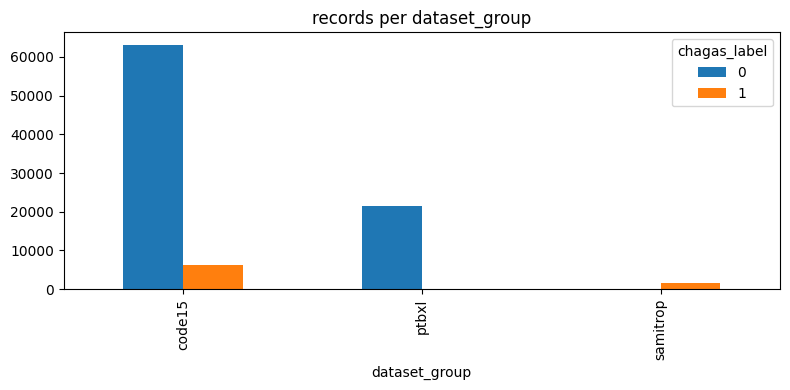

In [ ]:
counts = meta.groupby(['dataset_group', 'chagas_label']).size().unstack(fill_value=0)
print(counts)
counts.plot(kind='bar', figsize=(8, 4), title='records per dataset_group')
plt.tight_layout(); plt.show()

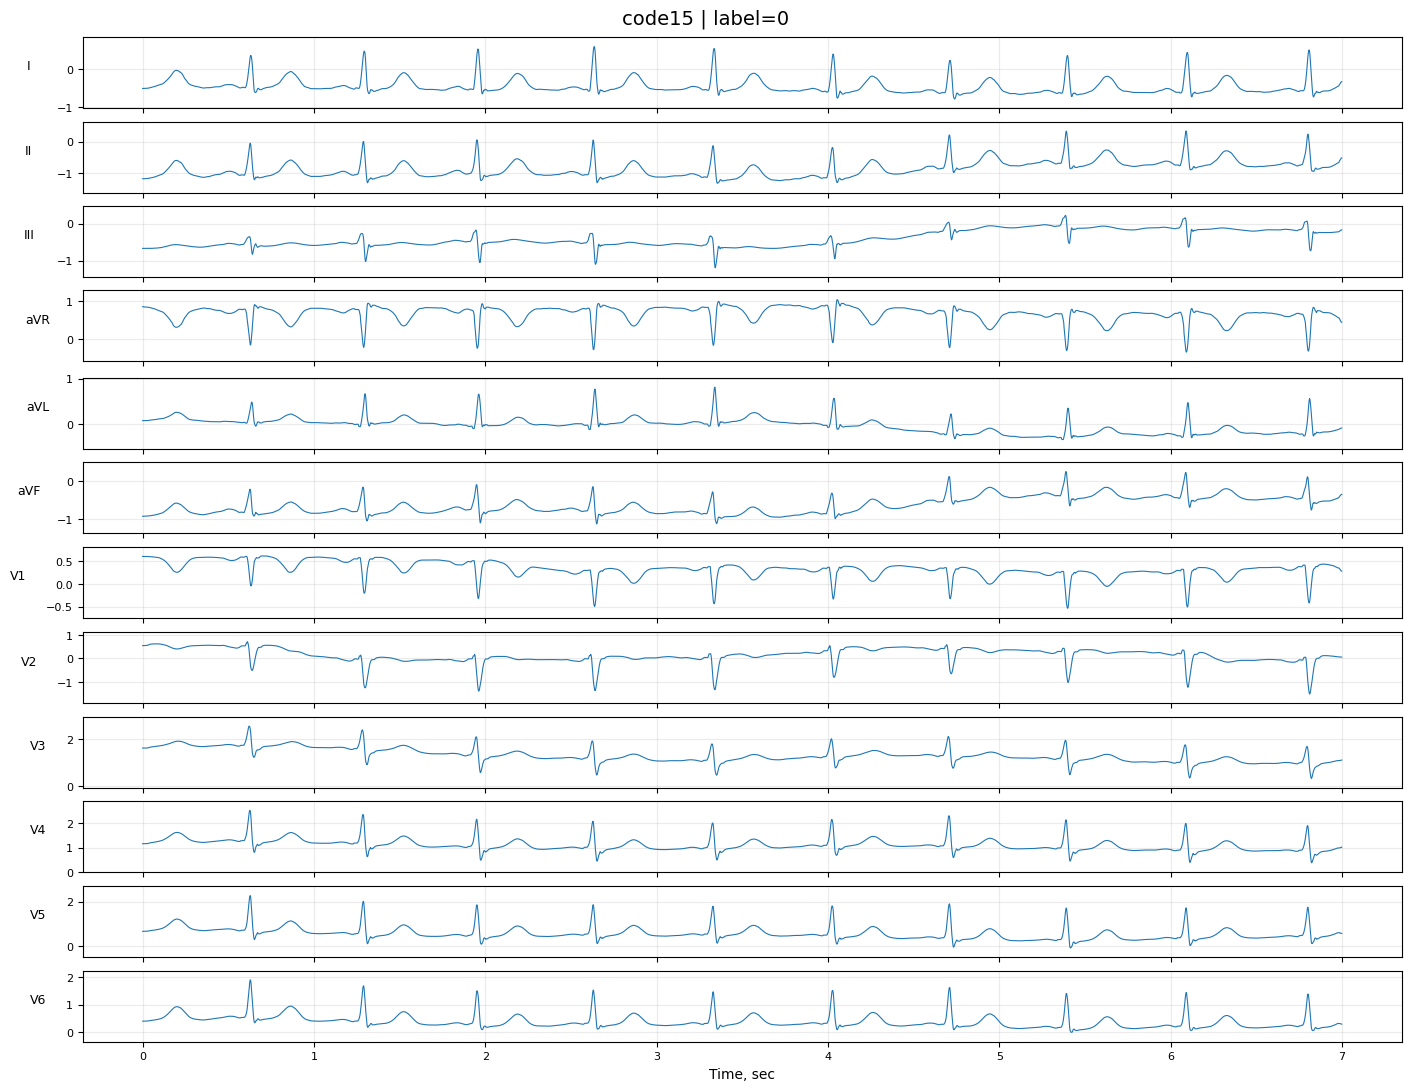

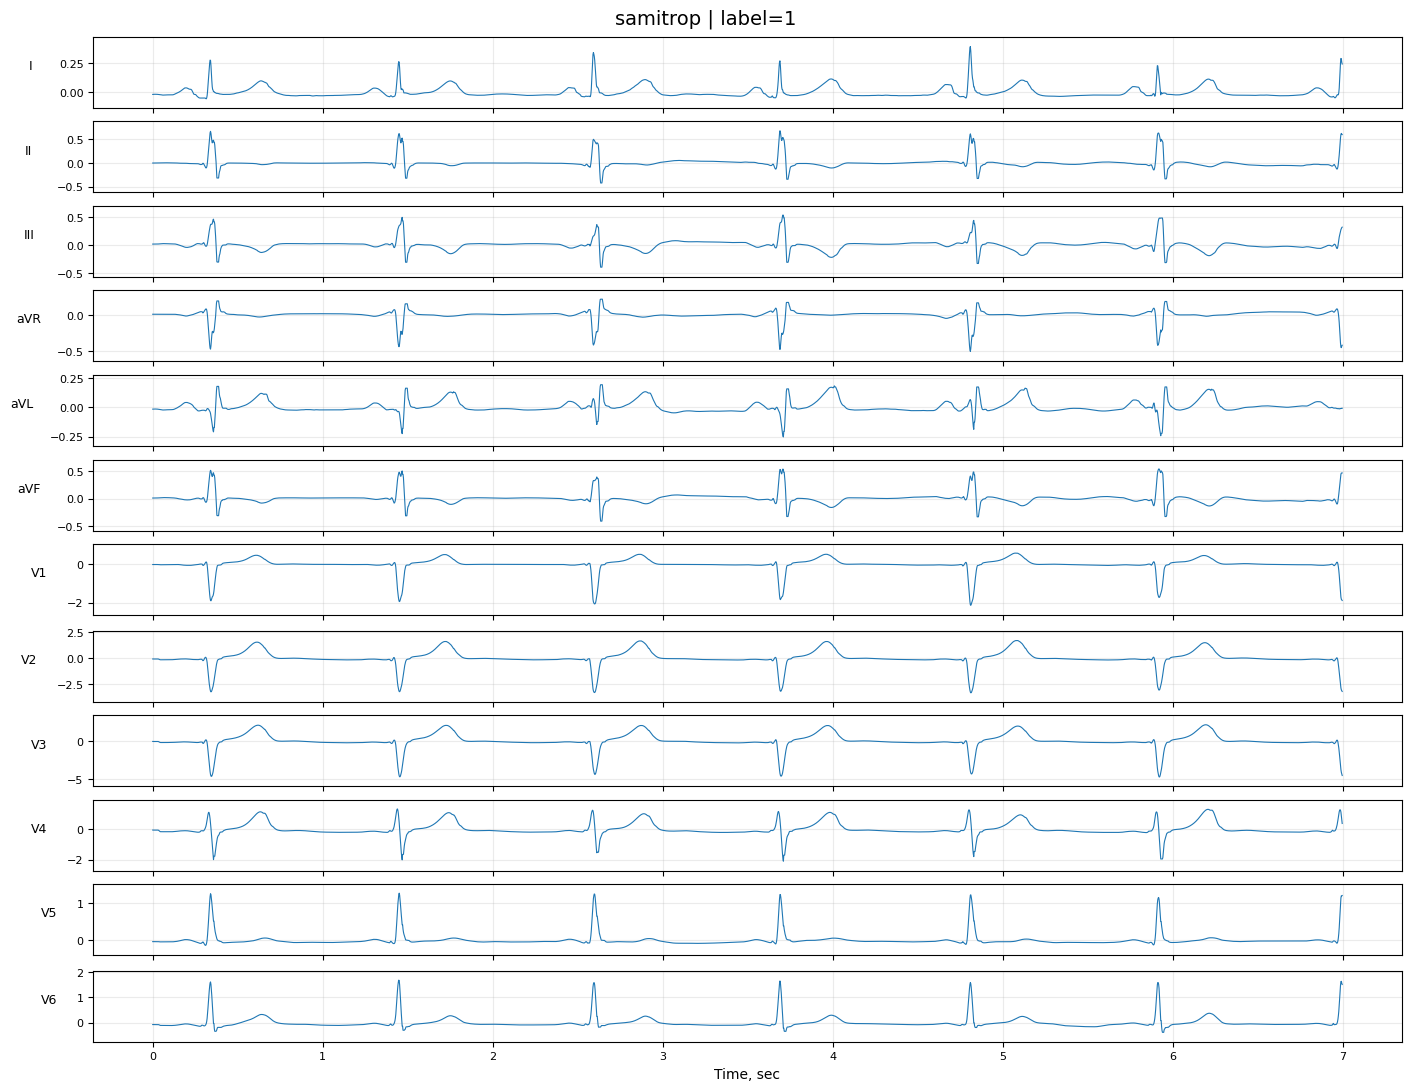

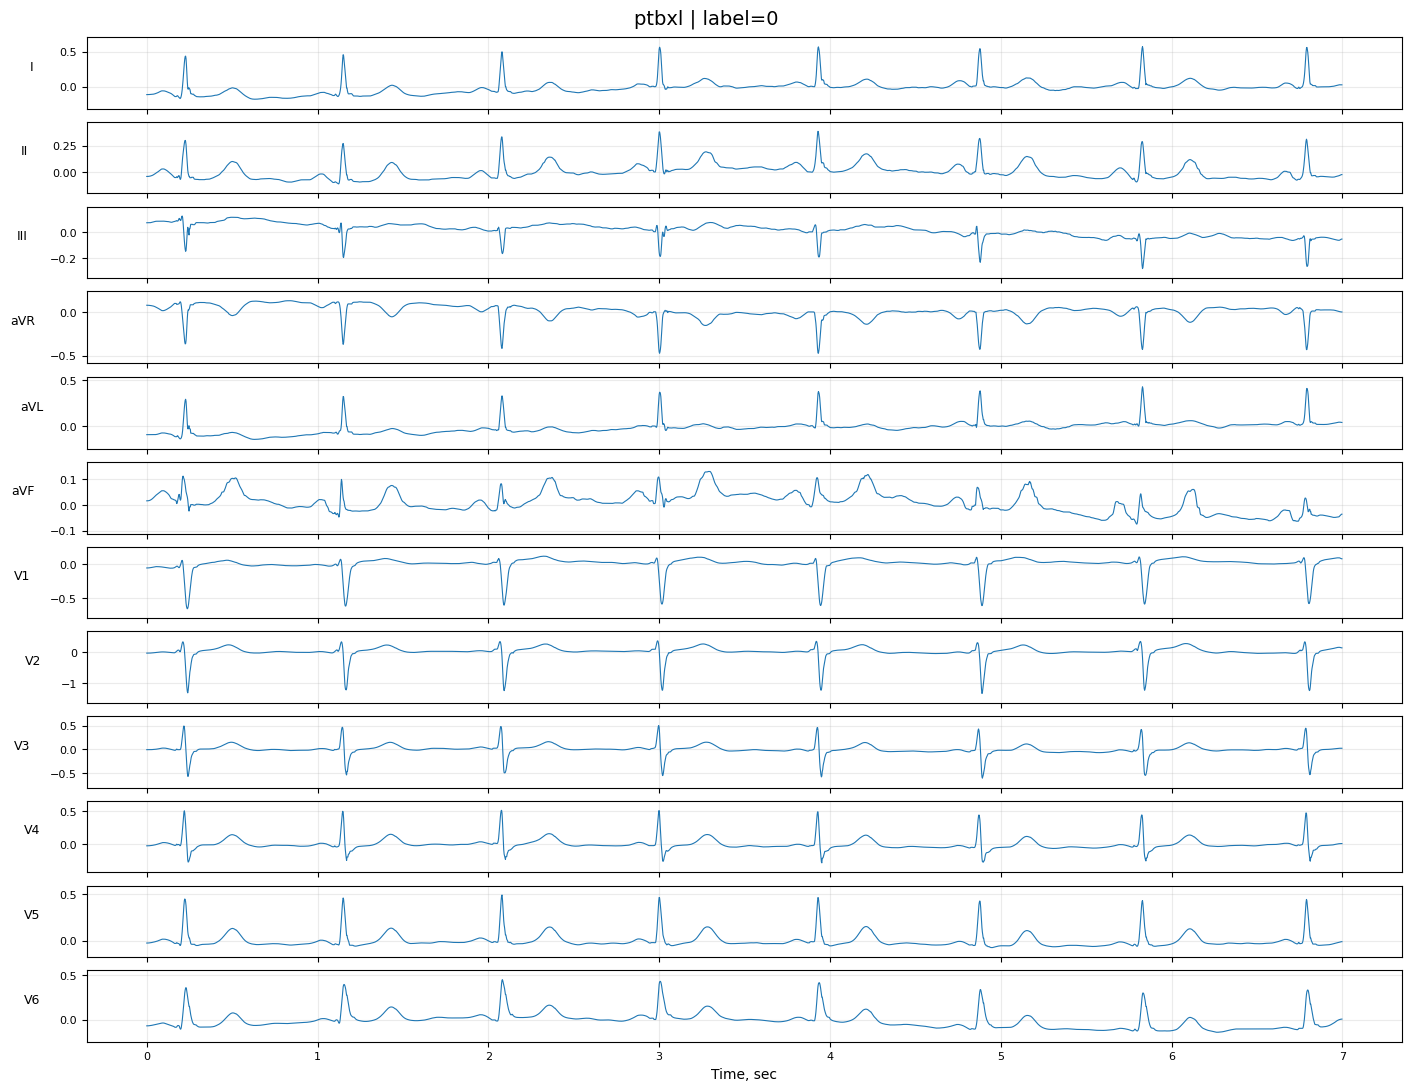

In [ ]:
from plot import plot_ecg

for group in meta['dataset_group'].unique():
    sub = meta[meta['dataset_group'] == group]
    if len(sub) == 0:
        continue
    si = int(sub.iloc[0]['signal_idx'])
    sig = np.array(signals[si])
    plot_ecg(sig, fs=400, title=f'{group} | label={int(sub.iloc[0]["chagas_label"])}')

In [ ]:
from splits import make_splits

train_df, val_df, test_df = make_splits(
    meta, samitrop_group='samitrop',
    n_test_samitrop=500,
    neg_test_frac=0.2,
    val_frac=0.2,
    random_state=42,
)

train: 60012 | pos=5762 neg=54250
val:   15004 | pos=1441 neg=13563
test:  17453 | pos=500 neg=16953 (samitrop=500)


In [ ]:
train_df.to_csv(META / 'train.csv', index=False)
val_df.to_csv(META / 'val.csv', index=False)
test_df.to_csv(META / 'test.csv', index=False)
print('saved splits')

saved splits


In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

BASE = Path('/content/drive/MyDrive/Diplom2')
META = BASE / 'data' / 'meta'
PRE_DIR = BASE / 'data' / 'preprocessed'
sys.path.insert(0, str(BASE / 'code'))

from splits import make_splits
meta = pd.read_csv(META / 'meta_raw.csv')

train_df, val_df, test_df = make_splits(
    meta, samitrop_group='samitrop',
    n_test_samitrop=500,
    neg_test_frac=0.2,
    val_frac=0.2,
    random_state=42,
)

train_df.to_csv(META / 'train.csv', index=False)
val_df.to_csv(META / 'val.csv', index=False)
test_df.to_csv(META / 'test.csv', index=False)
print('saved splits')

Mounted at /content/drive


/tmp/ipykernel_17009/1179212887.py:16: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  meta = pd.read_csv(META / 'meta_raw.csv')


train: 60012 (65%) | pos=5762 neg=54250
val: 15004 (16%) | pos=1441 neg=13563
test: 17453 (19%) | pos=500 neg=16953
saved splits
